In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import warnings
from astropy.wcs import WCS
from astropy.io import fits
from scipy.optimize import curve_fit, root_scalar
from spectral_cube import SpectralCube
from lmfit import Model, Parameters
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

warnings.filterwarnings('ignore')

In [2]:
# # File paths
# path = '/home/scratch/hfwest/RAMPS/'
# outdir = path+'Results/'
# suffixout='10sig'
# Cube = SpectralCube.read(path + 'Data/L28_5_NH3_1-1_cube.fits').with_spectral_unit(u.km/u.s)
# prefixout = 'L28_5_NH3_1-1'
# print(Cube.shape)

# plt.plot(Cube.spectral_axis[400:720], Cube[:, 320, 396][400:720])
# plt.title('NH$_3$(1,1) Spectrum')
# plt.ylabel('Intensity [K]')
# plt.xlabel('$V_{LSR}$ [km s$^{-1}$]')

# # Center
# plt.annotate('Main line', [80, 2.72], [62, 2.753], arrowprops=dict(color='gray'), fontsize='large')

# # Left side
# plt.annotate('Satellite lines', [72.5, 1.6], [55, 2], arrowprops=dict(color='gray'), fontsize='large')
# plt.annotate('', [61.5, 1.36], [57, 1.95], arrowprops=dict(color='gray'))

# # Right side
# plt.annotate('Satellite lines', [100.5, 1.55], [93, 2], arrowprops=dict(color='gray'), fontsize='large')
# plt.annotate('', [89.5, 1.45], [95, 1.95], arrowprops=dict(color='gray'))

# plt.savefig('/users/hfwest/GBO-REU/Plots/New-Example-Spectrum.png')
# plt.show()

In [10]:
Cube = SpectralCube.read('/home/scratch/hfwest/Pilot/Data/Pilot_NH3_11_cropped.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')
Quad_model = SpectralCube.read('/home/scratch/hfwest/Pilot/Results/Pilot_NH3_11_Fit_Pool.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')
Gauss_model = SpectralCube.read('/home/scratch/hfwest/Pilot/Results/Pilot_NH3_11_GaussFit_Pool.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.0

In [18]:
def plotter(x, y, cen = 200):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.set_figwidth(16)
    fig.set_figheight(8)

    max_val = np.nanmax(Cube[:, y, x].value)
    inc = max_val / 8

    ax1.plot(Cube[:, y, x].spectral_axis, Cube[:, y, x].value)
    ax1.set_title(f'Pilot region data\n({x}, {y}) pixel')

    ax2.plot(Quad_model[:, y, x].spectral_axis, Quad_model[:, y, x].value)
    ax2.set_title(f'Pilot region Quadrupole model\n({x}, {y}) pixel')

    ax3.plot(Gauss_model[:, y, x].spectral_axis, Gauss_model[:, y, x].value)
    ax3.set_title(f'Pilot region Gaussian model\n({x}, {y}) pixel')

    for ax in [ax1, ax2, ax3]:
        ax.set_ylim(-inc, max_val + inc)
        ax.set_xlim(cen - 50, cen + 50)

    plt.show()

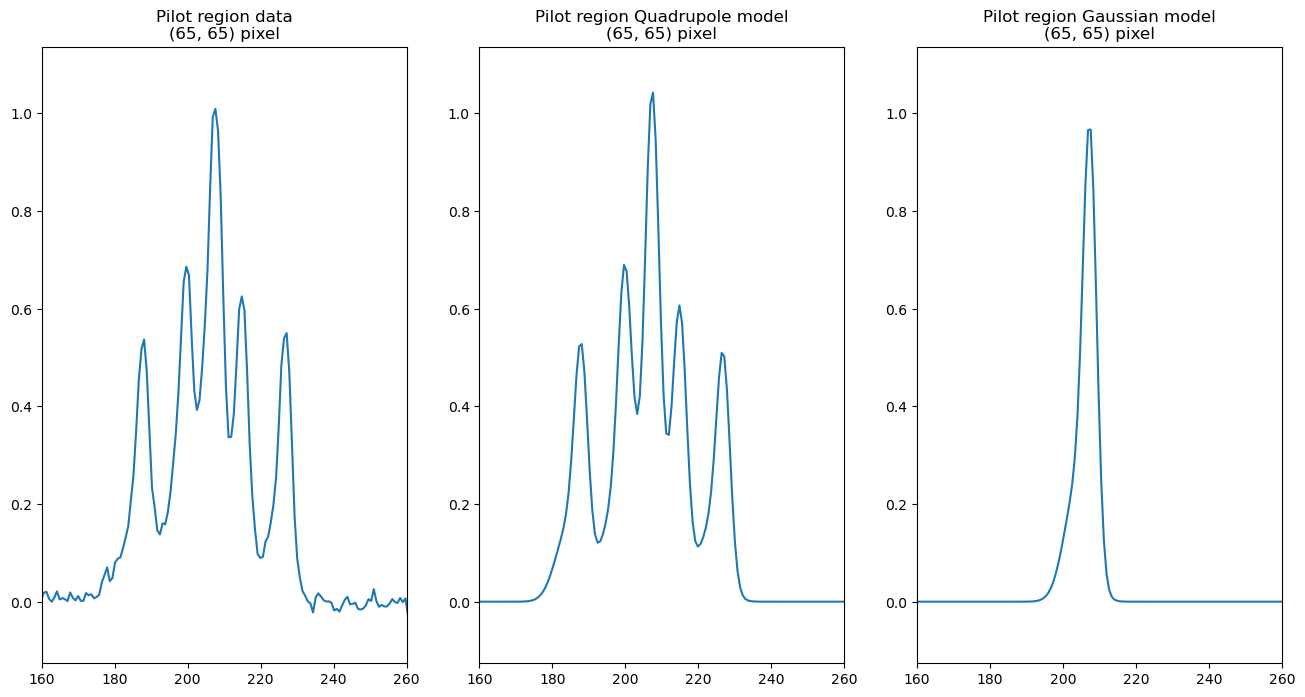

In [19]:
plotter(65, 65, 210)

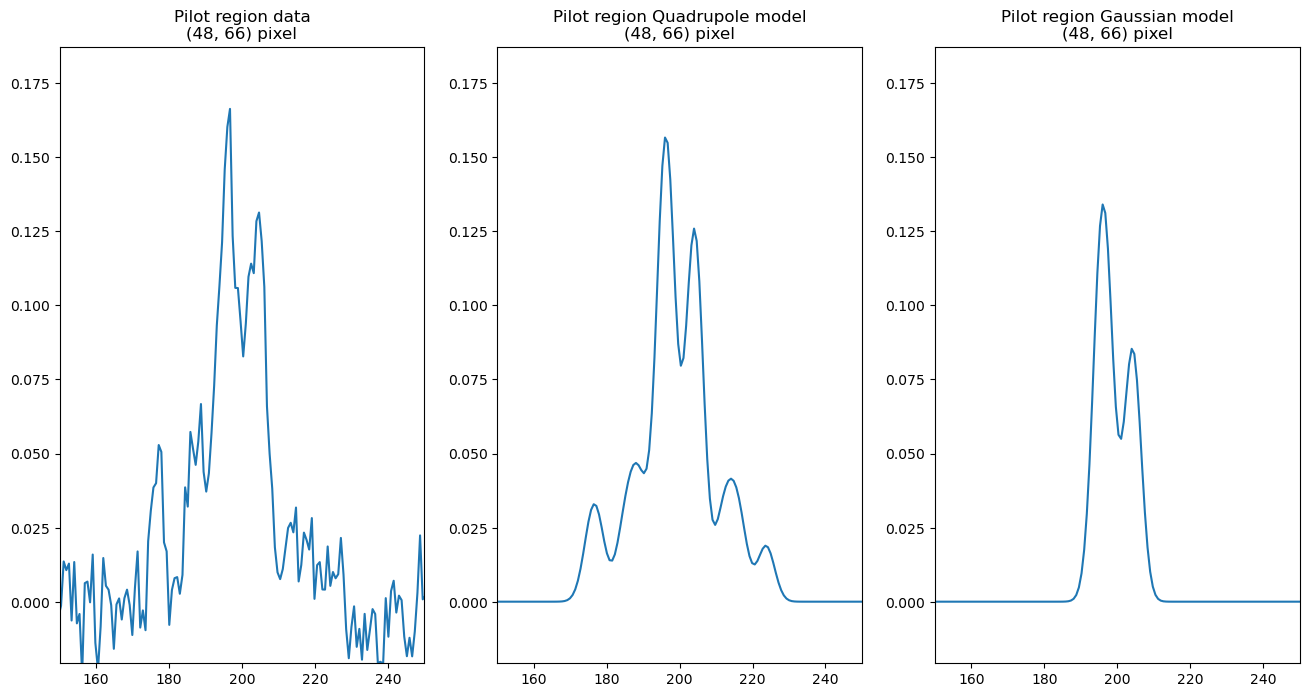

In [35]:
plotter(48, 66)